# Fourkiotis & Tsadiras (2024) — Weekly PharmaSales Baseline Comparison

This notebook compares two preprocessing approaches for the Fourkiotis & Tsadiras (2024) pharma weekly sales baselines:

**Reference-Based Exploration** — follows the paper's methodology: chronological 80/20 split, raw y values for statistical models (Naive, Seasonal Naive W, SES, DES, TES, ARIMA Rolling, ARIMA Long-Term), `lag_1` feature for XGBoost. Prophet and LSTM are placeholders pending implementation.

**Our Preprocessing** — uses our own pipeline: chronological 80/20 split, ACF-based lag selection (`max_lag=26`) + rolling mean features for ML models (XGBoost), raw y for statistical models.

**Models:** Naive, Seasonal Naive W, SES, DES, TES, ARIMA Rolling, ARIMA Long-Term, XGBoost (+ Prophet/LSTM placeholders).
**Metrics:** MSE, RMSE, and MAPE.


In [134]:
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM as KerasLSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.stattools import acf

from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

CATEGORIES = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
DATA_PATH = Path("../data/raw/pharma-sales/salesweekly.csv")
MAX_LAG = 26
SEASONAL_PERIOD = 52
RANDOM_STATE = 42

In [135]:
data = pd.read_csv(DATA_PATH)
data["datum"] = pd.to_datetime(data["datum"])
data = data.sort_values("datum").reset_index(drop=True)

missing_columns = sorted(set(["datum"] + CATEGORIES) - set(data.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

data[["datum"] + CATEGORIES].head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


# Helpers


In [136]:
def add_result(records, category, method, n_lags, train_mse, train_rmse, test_mse, test_rmse, test_mape=None, params=None, comment=None):
    records.append({
        "Category": category,
        "Method": method,
        "n_lags": n_lags,
        "params": json.dumps(params or {}, sort_keys=True),
        "Train MSE": train_mse,
        "Train RMSE": train_rmse,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "MAPE": test_mape if test_mape is not None else np.nan,
        "split": "chronological 80/20",
        "target_scale": "original weekly sales scale; no target scaling",
        "metric_family": "MSE/RMSE/MAPE",
        "comment": comment,
    })


# Model Architectures


In [137]:
def weighted_seasonal_naive_predict(train_y, test_y, seasonal_period=52, weights=None):
    if weights is None:
        weights = [0.4, 0.3, 0.2, 0.1]
    n_weights = len(weights)
    train_pred = np.zeros(len(train_y))
    for i in range(len(train_y)):
        past = []
        for w in range(n_weights):
            idx = i - seasonal_period * (w + 1)
            if idx >= 0:
                past.append(train_y[idx])
        if past:
            w_slice = weights[:len(past)]
            train_pred[i] = np.average(past, weights=np.array(w_slice) / sum(w_slice))
        else:
            train_pred[i] = train_y[0]
    test_pred = np.zeros(len(test_y))
    all_y = np.concatenate([train_y, test_y])
    test_start = len(train_y)
    for i in range(len(test_y)):
        past = []
        for w in range(n_weights):
            idx = test_start + i - seasonal_period * (w + 1)
            if idx >= 0:
                past.append(all_y[idx])
        if past:
            w_slice = weights[:len(past)]
            test_pred[i] = np.average(past, weights=np.array(w_slice) / sum(w_slice))
        else:
            test_pred[i] = train_y[-1]
    return train_pred, test_pred


# Reference-Based Exploration

Exploration follows the methodology from Fourkiotis & Tsadiras (2024). Preprocessing: chronological 80/20 split (train/test), raw y values for statistical models, `lag_1` feature for ML models (XGBoost). No ACF lag selection, no rolling mean. Hyperparameter tuning per model specifications in the paper. Metrics: MSE and MAPE.


## Preprocessing

Preprocessing follows the paper: weekly data loaded, split 80/20 chronologically. Statistical models use raw y time-series. ML models (XGBoost) use `lag_1` only. No ACF-based lag selection or rolling mean features.


In [138]:
ref_categories = []

for category in CATEGORIES:
    dfg = data[["datum", category]].rename(columns={"datum": "ds", category: "y"}).copy()
    dfg["ds"] = pd.to_datetime(dfg["ds"])
    dfg["lag_1"] = dfg["y"].shift(1)
    dfg = dfg.dropna().reset_index(drop=True)

    train_size = int(len(dfg) * 0.80)
    train_df = dfg.iloc[:train_size]
    test_df = dfg.iloc[train_size:]

    feature_columns = ["lag_1"]

    ref_categories.append({
        "Category": category,
        "feature_columns": feature_columns,
        "train_df": train_df,
        "test_df": test_df,
        "y_train": train_df["y"].to_numpy(dtype=float),
        "y_test": test_df["y"].to_numpy(dtype=float),
        "X_train": train_df[feature_columns].to_numpy(dtype=float),
        "X_test": test_df[feature_columns].to_numpy(dtype=float),
    })

pd.DataFrame([
    {
        "Category": item["Category"],
        "train_size": len(item["X_train"]),
        "test_size": len(item["X_test"]),
    }
    for item in ref_categories
])


,Category,train_size,test_size
0,M01AB,240,61
1,M01AE,240,61
2,N02BA,240,61
3,N02BE,240,61
4,N05B,240,61
5,N05C,240,61
6,R03,240,61
7,R06,240,61


## Modeling

Ten forecasting models evaluated with reference preprocessing. Statistical models use raw y values; ML models use `lag_1` feature. Prophet and LSTM are marked as placeholders pending implementation.


### Naive

Simple Naive forecast: `y_pred[t] = y[t-1]`.


In [139]:
ref_records = []
_Naive_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    train_pred = np.array([train_y[i-1] if i > 0 else train_y[0] for i in range(len(train_y))])
    test_pred = np.array([train_y[-1]] + list(test_y[:-1]))

    train_pred_clip = np.maximum(np.asarray(train_pred, dtype=float), 0)
    test_pred_clip = np.maximum(np.asarray(test_pred, dtype=float), 0)
    train_mse = float(mean_squared_error(train_y, train_pred_clip))
    train_rmse = float(root_mean_squared_error(train_y, train_pred_clip))
    test_mse = float(mean_squared_error(test_y, test_pred_clip))
    test_rmse = float(root_mean_squared_error(test_y, test_pred_clip))
    mask = test_y != 0
    test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred_clip[mask])) if mask.sum() > 0 else np.nan

    add_result(_Naive_results, category, "Naive", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, comment="y_pred[t] = y[t-1]")

ref_records.extend(_Naive_results)
pd.DataFrame(_Naive_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,Naive,0,{},116.487455,10.792935,100.176669,10.008830,0.261467,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]
1,M01AE,Naive,0,{},58.499755,7.648513,83.291220,9.126402,0.329417,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]
2,N02BA,Naive,0,{},77.852007,8.823378,45.478852,6.743801,0.331775,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]
3,N02BE,Naive,0,{},2107.236737,45.904648,2732.873738,52.276895,0.209746,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]
4,N05B,Naive,0,{},566.194318,23.794838,262.086557,16.189088,0.242410,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]
5,N05C,Naive,0,{},17.135735,4.139533,14.622951,3.823997,0.965801,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]
6,R03,Naive,0,{},441.208428,21.004962,904.344547,30.072322,0.450141,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]
7,R06,Naive,0,{},57.320211,7.571011,79.018279,8.889223,0.501683,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]


### Seasonal Naive (Weighted)

Weighted Seasonal Naive with 52-week period, weights `[0.4, 0.3, 0.2, 0.1]` giving more importance to recent years (as per paper Table 1).


In [140]:
_Seasonal_Naive_W_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]
    weights = [0.4, 0.3, 0.2, 0.1]

    train_pred, test_pred = weighted_seasonal_naive_predict(train_y, test_y, SEASONAL_PERIOD, weights)

    train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
    test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    train_rmse = float(root_mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))
    test_rmse = float(root_mean_squared_error(test_y, test_pred))
    mask = test_y != 0
    test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan

    add_result(_Seasonal_Naive_W_results, category, "Seasonal Naive W", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, {"seasonal_period": SEASONAL_PERIOD, "weights": weights}, "Weighted Seasonal Naive 52-week")

ref_records.extend(_Seasonal_Naive_W_results)
pd.DataFrame(_Seasonal_Naive_W_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",109.065768,10.443456,72.015581,8.486199,0.237000,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week
1,M01AE,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",83.148990,9.118607,82.641344,9.090728,0.336939,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week
2,N02BA,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",80.899086,8.994392,73.248956,8.558560,0.451500,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week
3,N02BE,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",4331.727694,65.815862,2357.228876,48.551301,0.177334,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week
4,N05B,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",906.645986,30.110563,211.764610,14.552134,0.210566,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week
5,N05C,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",14.158428,3.762769,11.019413,3.319550,0.677198,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week
6,R03,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",367.170209,19.161686,1024.350090,32.005470,0.491917,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week
7,R06,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",84.225038,9.177420,80.338479,8.963173,0.508508,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week


### Exponential Smoothing (SES, DES, TES)

Simple (SES), Double (DES/Holt), and Triple (TES/Holt-Winters) Exponential Smoothing. Parameters optimized via statsmodels `fit(optimized=True)`.


In [141]:
_Model_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    smoothing_specs = [
        ("SES", SimpleExpSmoothing, {"initialization_method": "estimated"}, {}),
        ("DES", ExponentialSmoothing, {"trend": "add", "seasonal": None, "initialization_method": "estimated"}, {}),
        ("TES", ExponentialSmoothing, {"trend": "add", "seasonal": "add", "seasonal_periods": min(SEASONAL_PERIOD, max(2, len(train_y) // 2)), "initialization_method": "estimated"}, {"seasonal_period": min(SEASONAL_PERIOD, max(2, len(train_y) // 2))}),
    ]

    for method, model_class, model_kwargs, params in smoothing_specs:
        try:
            model = model_class(train_y, **model_kwargs)
            fit = model.fit(optimized=True)
            train_pred = fit.fittedvalues
            test_pred = fit.forecast(len(test_y))

            train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
            test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
            train_mse = float(mean_squared_error(train_y[-len(train_pred):], train_pred))
            train_rmse = float(root_mean_squared_error(train_y[-len(train_pred):], train_pred))
            test_mse = float(mean_squared_error(test_y, test_pred))
            test_rmse = float(root_mean_squared_error(test_y, test_pred))
            mask = test_y != 0
            test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan
            comment = "Reference SES/DES/TES on raw y."
        except Exception as exc:
            train_mse = train_rmse = test_mse = test_rmse = np.nan
            test_mape_val = np.nan
            comment = f"{method} failed: {repr(exc)}"

        add_result(_Model_results, category, method, 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, params, comment)

ref_records.extend(_Model_results)
pd.DataFrame(_Model_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,SES,0,{},59.963616,7.743618,66.438894,8.151006,0.202414,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
1,M01AB,DES,0,{},59.928953,7.741379,62.983627,7.936222,0.201244,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
2,M01AB,TES,0,"{""seasonal_period"": 52}",47.348516,6.881026,72.213044,8.497826,0.225330,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
3,M01AE,SES,0,{},36.150773,6.012551,86.510327,9.301093,0.309010,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
4,M01AE,DES,0,{},36.140463,6.011694,87.302126,9.343561,0.316059,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
5,M01AE,TES,0,"{""seasonal_period"": 52}",25.466021,5.046387,86.186126,9.283648,0.353964,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
6,N02BA,SES,0,{},47.793320,6.913271,29.031728,5.388110,0.273907,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
7,N02BA,DES,0,{},47.565701,6.896789,36.363237,6.030194,0.264470,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
8,N02BA,TES,0,"{""seasonal_period"": 52}",28.326524,5.322267,45.281634,6.729163,0.306847,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
9,N02BE,SES,0,{},1918.342880,43.798891,11483.951980,107.163203,0.324705,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.


### ARIMA Rolling

ARIMA with rolling expanding window forecast. Order selected via auto_arima (p:0-5, d:0-1, q:0-5) with fallback to (1,1,1).


In [142]:
_ARIMA_Rolling_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    try:
        initial_model = auto_arima(train_y, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=5, max_q=5, max_d=2)
        order = tuple(initial_model.order)
        comment = "auto_arima on reference y."

        fitted_train = ARIMA(train_y, order=order).fit()
        train_pred = fitted_train.predict(start=0, end=len(train_y) - 1)

        history = list(train_y)
        test_pred = []
        for actual in test_y:
            model = ARIMA(history, order=order)
            model_fit = model.fit()
            test_pred.append(model_fit.forecast(steps=1)[0])
            history.append(actual)

        train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
        test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        train_rmse = float(root_mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        test_rmse = float(root_mean_squared_error(test_y, test_pred))
        mask = test_y != 0
        test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan
        params = {"order": list(order)}
    except Exception as exc:
        train_mse = train_rmse = test_mse = test_rmse = np.nan
        test_mape_val = np.nan
        params = {}
        comment = f"ARIMA Rolling failed: {repr(exc)}"

    add_result(_ARIMA_Rolling_results, category, "ARIMA Rolling", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, params, comment)

ref_records.extend(_ARIMA_Rolling_results)
pd.DataFrame(_ARIMA_Rolling_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,ARIMA Rolling,0,"{""order"": [0, 1, 1]}",63.679097,7.979918,65.122101,8.069827,0.211146,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.
1,M01AE,ARIMA Rolling,0,"{""order"": [1, 1, 1]}",36.805943,6.066790,74.137333,8.610304,0.313565,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.
2,N02BA,ARIMA Rolling,0,"{""order"": [0, 1, 1]}",54.383537,7.374519,30.970286,5.565095,0.282163,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.
3,N02BE,ARIMA Rolling,0,"{""order"": [2, 0, 0]}",1820.665791,42.669260,2525.413100,50.253488,0.197234,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.
4,N05B,ARIMA Rolling,0,"{""order"": [0, 1, 1]}",415.965433,20.395231,149.741650,12.236897,0.184389,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.
5,N05C,ARIMA Rolling,0,"{""order"": [0, 0, 1]}",9.979151,3.158979,7.812116,2.795016,0.623082,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.
6,R03,ARIMA Rolling,0,"{""order"": [0, 1, 1]}",285.931172,16.909499,677.915951,26.036819,0.478674,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.
7,R06,ARIMA Rolling,0,"{""order"": [2, 0, 2]}",43.290403,6.579544,70.254707,8.381808,0.510360,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.


### ARIMA Long-Term

ARIMA with long-term forecast (52 weeks). Order selected via grid search (p:0-5, d:0-2, q:0-5). Test uses last 52 weeks.


In [143]:
_ARIMA_Long_Term_results = []

for item in ref_categories:
    category = item["Category"]
    train_y_full = item["y_train"]
    test_y = item["y_test"]

    try:
        best_mse = np.inf
        best_order = (1, 1, 1)
        for p in range(0, 4):
            for d in range(0, 2):
                for q in range(0, 4):
                    try:
                        model = ARIMA(train_y_full, order=(p, d, q))
                        fitted = model.fit()
                        pred = fitted.predict(start=0, end=len(train_y_full) - 1)
                        mse_val = mean_squared_error(train_y_full, pred)
                        if mse_val < best_mse:
                            best_mse = mse_val
                            best_order = (p, d, q)
                    except Exception:
                        continue

        fitted = ARIMA(train_y_full, order=best_order).fit()
        train_pred = fitted.predict(start=0, end=len(train_y_full) - 1)
        test_pred = fitted.forecast(steps=len(test_y))

        train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
        test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
        train_mse = float(mean_squared_error(train_y_full, train_pred))
        train_rmse = float(root_mean_squared_error(train_y_full, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        test_rmse = float(root_mean_squared_error(test_y, test_pred))
        mask = test_y != 0
        test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan
        params = {"order": list(best_order)}
        comment = "ARIMA Long-Term grid search."
    except Exception as exc:
        train_mse = train_rmse = test_mse = test_rmse = np.nan
        test_mape_val = np.nan
        params = {}
        comment = f"ARIMA Long-Term failed: {repr(exc)}"

    add_result(_ARIMA_Long_Term_results, category, "ARIMA Long-Term", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, params, comment)

ref_records.extend(_ARIMA_Long_Term_results)
pd.DataFrame(_ARIMA_Long_Term_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,ARIMA Long-Term,0,"{""order"": [3, 0, 3]}",56.096890,7.489786,77.560742,8.806858,0.230498,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.
1,M01AE,ARIMA Long-Term,0,"{""order"": [3, 0, 3]}",34.955703,5.912335,86.962432,9.325365,0.318930,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.
2,N02BA,ARIMA Long-Term,0,"{""order"": [3, 0, 3]}",47.031080,6.857921,50.861860,7.131750,0.411054,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.
3,N02BE,ARIMA Long-Term,0,"{""order"": [3, 0, 3]}",1763.457877,41.993546,6888.533929,82.997192,0.355285,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.
4,N05B,ARIMA Long-Term,0,"{""order"": [3, 0, 3]}",360.743743,18.993255,160.470435,12.667693,0.206629,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.
5,N05C,ARIMA Long-Term,0,"{""order"": [3, 0, 3]}",9.524693,3.086210,8.118660,2.849326,0.607391,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.
6,R03,ARIMA Long-Term,0,"{""order"": [3, 0, 3]}",266.570529,16.326988,1361.475601,36.898179,0.505315,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.
7,R06,ARIMA Long-Term,0,"{""order"": [3, 0, 2]}",43.281282,6.578851,117.724378,10.850087,0.541031,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.


### XGBoost

XGBoost regressor with GridSearchCV + TimeSeriesSplit. Features: `lag_1` only (as per paper). Split: 80/20.


In [144]:
_XGBoost_results = []

param_grid = {
    "n_estimators": [30, 50, 100, 150, 200, 300],
    "max_depth": [2, 3, 5, 7],
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
}

for item in ref_categories:
    category = item["Category"]
    X_train = item["X_train"]
    y_train = item["y_train"]
    X_test = item["X_test"]
    y_test = item["y_test"]

    tscv = TimeSeriesSplit(n_splits=3)
    xgb_base = xgb.XGBRegressor(objective="reg:squarederror", subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1)
    grid_search = GridSearchCV(xgb_base, param_grid, scoring="neg_mean_squared_error", cv=tscv)
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_

    xgb_final = xgb.XGBRegressor(objective="reg:squarederror", subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, **best_params)
    xgb_final.fit(X_train, y_train)

    train_pred = xgb_final.predict(X_train)
    test_pred = xgb_final.predict(X_test)

    train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
    test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
    train_mse = float(mean_squared_error(y_train, train_pred))
    train_rmse = float(root_mean_squared_error(y_train, train_pred))
    test_mse = float(mean_squared_error(y_test, test_pred))
    test_rmse = float(root_mean_squared_error(y_test, test_pred))
    mask = y_test != 0
    test_mape_val = float(mean_absolute_percentage_error(y_test[mask], test_pred[mask])) if mask.sum() > 0 else np.nan

    add_result(_XGBoost_results, category, "XGBoost", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, best_params, "Reference XGBoost with lag_1 only.")

ref_records.extend(_XGBoost_results)
pd.DataFrame(_XGBoost_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,XGBoost,0,"{""learning_rate"": 0.01, ""max_depth"": 3, ""n_est...",67.582639,8.220866,62.843238,7.927373,0.203711,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference XGBoost with lag_1 only.
1,M01AE,XGBoost,0,"{""learning_rate"": 0.01, ""max_depth"": 2, ""n_est...",35.066745,5.921718,79.325771,8.906502,0.312111,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference XGBoost with lag_1 only.
2,N02BA,XGBoost,0,"{""learning_rate"": 0.01, ""max_depth"": 3, ""n_est...",50.752272,7.124063,72.878789,8.536907,0.488355,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference XGBoost with lag_1 only.
3,N02BE,XGBoost,0,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",1467.203760,38.304096,2364.115447,48.622170,0.193728,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference XGBoost with lag_1 only.
4,N05B,XGBoost,0,"{""learning_rate"": 0.01, ""max_depth"": 2, ""n_est...",407.736563,20.192488,161.246227,12.698277,0.189012,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference XGBoost with lag_1 only.
5,N05C,XGBoost,0,"{""learning_rate"": 0.01, ""max_depth"": 2, ""n_est...",9.633482,3.103785,7.999774,2.828387,0.611238,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference XGBoost with lag_1 only.
6,R03,XGBoost,0,"{""learning_rate"": 0.05, ""max_depth"": 2, ""n_est...",267.423216,16.353080,953.721084,30.882375,0.424909,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference XGBoost with lag_1 only.
7,R06,XGBoost,0,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",39.945065,6.320211,82.705327,9.094247,0.500993,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference XGBoost with lag_1 only.


### Facebook Prophet

Prophet additive forecasting model by Meta. Uses weekly and yearly seasonality with linear growth (per paper Table 1). Fits on raw y time-series with date index.


In [145]:
_Prophet_results = []

for item in ref_categories:
    category = item["Category"]
    train_df = item["train_df"][["ds", "y"]].copy()
    test_df = item["test_df"][["ds", "y"]].copy()

    try:
        model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto", interval_width=0.0005)
        model.fit(train_df)
        future = model.make_future_dataframe(periods=len(test_df), freq="W")
        forecast = model.predict(future)

        train_pred = forecast["yhat"].to_numpy(dtype=float)[:len(train_df)]
        test_pred = forecast["yhat"].to_numpy(dtype=float)[-len(test_df):]

        train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
        test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
        train_mse = float(mean_squared_error(item["y_train"], train_pred))
        train_rmse = float(root_mean_squared_error(item["y_train"], train_pred))
        test_mse = float(mean_squared_error(item["y_test"], test_pred))
        test_rmse = float(root_mean_squared_error(item["y_test"], test_pred))
        mask = item["y_test"] != 0
        test_mape_val = float(mean_absolute_percentage_error(item["y_test"][mask], test_pred[mask])) if mask.sum() > 0 else np.nan
        comment = "Prophet with linear growth on reference y."
    except Exception as exc:
        train_mse = train_rmse = test_mse = test_rmse = np.nan
        test_mape_val = np.nan
        comment = f"Prophet failed: {repr(exc)}"

    add_result(_Prophet_results, category, "Prophet", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, {}, comment)

ref_records.extend(_Prophet_results)
pd.DataFrame(_Prophet_results)


17:36:54 - cmdstanpy - INFO - Chain [1] start processing
17:36:54 - cmdstanpy - INFO - Chain [1] done processing
17:36:54 - cmdstanpy - INFO - Chain [1] start processing
17:36:54 - cmdstanpy - INFO - Chain [1] done processing
17:36:55 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1] done processing
17:36:55 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1] done processing
17:36:55 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1] done processing
17:36:55 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1] done processing
17:36:55 - cmdstanpy - INFO - Chain [1] start processing
17:36:56 - cmdstanpy - INFO - Chain [1] done processing
17:36:56 - cmdstanpy - INFO - Chain [1] start processing
17:36:56 - cmdstanpy - INFO - Chain [1] done processing


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,Prophet,0,{},54.610793,7.389912,84.403873,9.187158,0.230151,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.
1,M01AE,Prophet,0,{},28.554179,5.343611,75.674990,8.699137,0.287502,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.
2,N02BA,Prophet,0,{},38.245635,6.184306,44.027534,6.635325,0.290422,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.
3,N02BE,Prophet,0,{},1864.026502,43.174373,3541.740821,59.512527,0.197495,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.
4,N05B,Prophet,0,{},452.573197,21.273768,248.061191,15.749958,0.206557,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.
5,N05C,Prophet,0,{},9.268402,3.044405,10.700755,3.271201,0.562848,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.
6,R03,Prophet,0,{},218.170035,14.770580,807.716721,28.420358,0.482438,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.
7,R06,Prophet,0,{},37.507320,6.124322,73.032263,8.545892,0.566233,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.


### LSTM Neural Network

Long Short-Term Memory neural network. Input: 3-step sliding window of `lag_1` feature. Architecture: LSTM(50) → Dropout(0.2) → Dense(1). Adam optimizer, MSE loss, 100 epochs with early stopping (patience=10). Per paper: 3-step input, single feature, ReLU activation implicit in RNN gates.


In [146]:
_LSTM_results = []

N_STEPS = 3

for item in ref_categories:
    category = item["Category"]
    X_train = item["X_train"]
    y_train = item["y_train"]
    X_test = item["X_test"]
    y_test = item["y_test"]

    print(f"Running {category}...")

    try:
        # --- Create sequences (3-step sliding window) ---
        X_train_seq, y_train_seq = [], []
        for i in range(N_STEPS, len(X_train)):
            X_train_seq.append(X_train[i-N_STEPS:i].flatten())
            y_train_seq.append(y_train[i])
        X_train_seq = np.array(X_train_seq).reshape(-1, N_STEPS, X_train.shape[1])
        y_train_seq = np.array(y_train_seq)

        X_test_seq, y_test_seq = [], []
        for i in range(N_STEPS, len(X_test)):
            X_test_seq.append(X_test[i-N_STEPS:i].flatten())
            y_test_seq.append(y_test[i])
        X_test_seq = np.array(X_test_seq).reshape(-1, N_STEPS, X_test.shape[1])
        y_test_seq = np.array(y_test_seq)

        # --- Build LSTM ---
        model = Sequential([
            KerasLSTM(50, activation="relu", return_sequences=False, input_shape=(N_STEPS, X_train.shape[1])),
            Dropout(0.2),
            Dense(1)
        ])
        model.compile(optimizer="adam", loss="mse")
        model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=16, validation_split=0.1, verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])

        train_pred = model.predict(X_train_seq, verbose=0).flatten()
        test_pred = model.predict(X_test_seq, verbose=0).flatten()

        # Match original train_y length (first N_STEPS have no prediction)
        train_pred_full = np.full(len(y_train), np.mean(y_train))
        train_pred_full[-len(train_pred):] = train_pred
        test_pred_full = np.full(len(y_test), np.mean(y_train))
        test_pred_full[N_STEPS:] = test_pred

        train_pred_full = np.maximum(train_pred_full, 0)
        test_pred_full = np.maximum(test_pred_full, 0)
        train_mse = float(mean_squared_error(y_train, train_pred_full))
        train_rmse = float(root_mean_squared_error(y_train, train_pred_full))
        test_mse = float(mean_squared_error(y_test, test_pred_full))
        test_rmse = float(root_mean_squared_error(y_test, test_pred_full))
        mask = y_test != 0
        test_mape_val = float(mean_absolute_percentage_error(y_test[mask], test_pred_full[mask])) if mask.sum() > 0 else np.nan
        comment = "LSTM 3-step window on reference lag_1."
    except Exception as exc:
        train_mse = train_rmse = test_mse = test_rmse = np.nan
        test_mape_val = np.nan
        comment = f"LSTM failed: {repr(exc)}"

    add_result(_LSTM_results, category, "LSTM", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, {"n_steps": N_STEPS}, comment)

ref_records.extend(_LSTM_results)
pd.DataFrame(_LSTM_results)


Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,LSTM,0,"{""n_steps"": 3}",61.894161,7.867284,69.358500,8.328175,0.211268,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.
1,M01AE,LSTM,0,"{""n_steps"": 3}",39.262946,6.266015,89.890038,9.481036,0.312482,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.
2,N02BA,LSTM,0,"{""n_steps"": 3}",61.130395,7.818593,43.543645,6.598761,0.316133,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.
3,N02BE,LSTM,0,"{""n_steps"": 3}",2974.412592,54.538176,4187.279278,64.709190,0.223079,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.
4,N05B,LSTM,0,"{""n_steps"": 3}",451.605301,21.251007,154.360394,12.424186,0.186372,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.
5,N05C,LSTM,0,"{""n_steps"": 3}",11.261711,3.355847,8.907853,2.984603,0.642436,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.
6,R03,LSTM,0,"{""n_steps"": 3}",330.972509,18.192650,922.352980,30.370265,0.507467,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.
7,R06,LSTM,0,"{""n_steps"": 3}",56.079877,7.488650,88.681571,9.417089,0.687622,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.


## Reference Results

Combine all reference model results into one DataFrame.


In [147]:
ref_results_df = pd.DataFrame(ref_records).sort_values(["Category", "Method"])
ref_results_df["params"] = ref_results_df["params"].apply(lambda p: json.dumps(p, sort_keys=True) if isinstance(p, dict) else p)
ref_results_df


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
48,M01AB,ARIMA Long-Term,0,"{""order"": [3, 0, 3]}",56.096890,7.489786,77.560742,8.806858,0.230498,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term grid search.
40,M01AB,ARIMA Rolling,0,"{""order"": [0, 1, 1]}",63.679097,7.979918,65.122101,8.069827,0.211146,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on reference y.
17,M01AB,DES,0,{},59.928953,7.741379,62.983627,7.936222,0.201244,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
72,M01AB,LSTM,0,"{""n_steps"": 3}",61.894161,7.867284,69.358500,8.328175,0.211268,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM 3-step window on reference lag_1.
0,M01AB,Naive,0,{},116.487455,10.792935,100.176669,10.008830,0.261467,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,y_pred[t] = y[t-1]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,R06,Prophet,0,{},37.507320,6.124322,73.032263,8.545892,0.566233,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet with linear growth on reference y.
37,R06,SES,0,{},47.315786,6.878647,151.598951,12.312553,0.984577,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.
15,R06,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",84.225038,9.177420,80.338479,8.963173,0.508508,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive 52-week
39,R06,TES,0,"{""seasonal_period"": 52}",33.235738,5.765044,72.708922,8.526953,0.702589,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Reference SES/DES/TES on raw y.


## Best Baseline & Export (Reference)

Best model per category based on lowest Test MSE. Includes line chart comparison.


In [148]:
ref_best = ref_results_df.loc[ref_results_df.groupby("Category")["Test MSE"].idxmin()].reset_index(drop=True)

# Best per category — long format
ref_table = ref_best[["Category", "Method", "Test MSE", "Test RMSE", "MAPE"]].reset_index(drop=True)
ref_table


,Category,Method,Test MSE,Test RMSE,MAPE
0,M01AB,XGBoost,62.843238,7.927373,0.203711
1,M01AE,ARIMA Rolling,74.137333,8.610304,0.313565
2,N02BA,SES,29.031728,5.388110,0.273907
3,N02BE,Seasonal Naive W,2357.228876,48.551301,0.177334
4,N05B,DES,139.128637,11.795280,0.186422
5,N05C,SES,7.600477,2.756896,0.593323
6,R03,ARIMA Rolling,677.915951,26.036819,0.478674
7,R06,ARIMA Rolling,70.254707,8.381808,0.510360


### Plot actual vs predicted for best model per category (Reference)

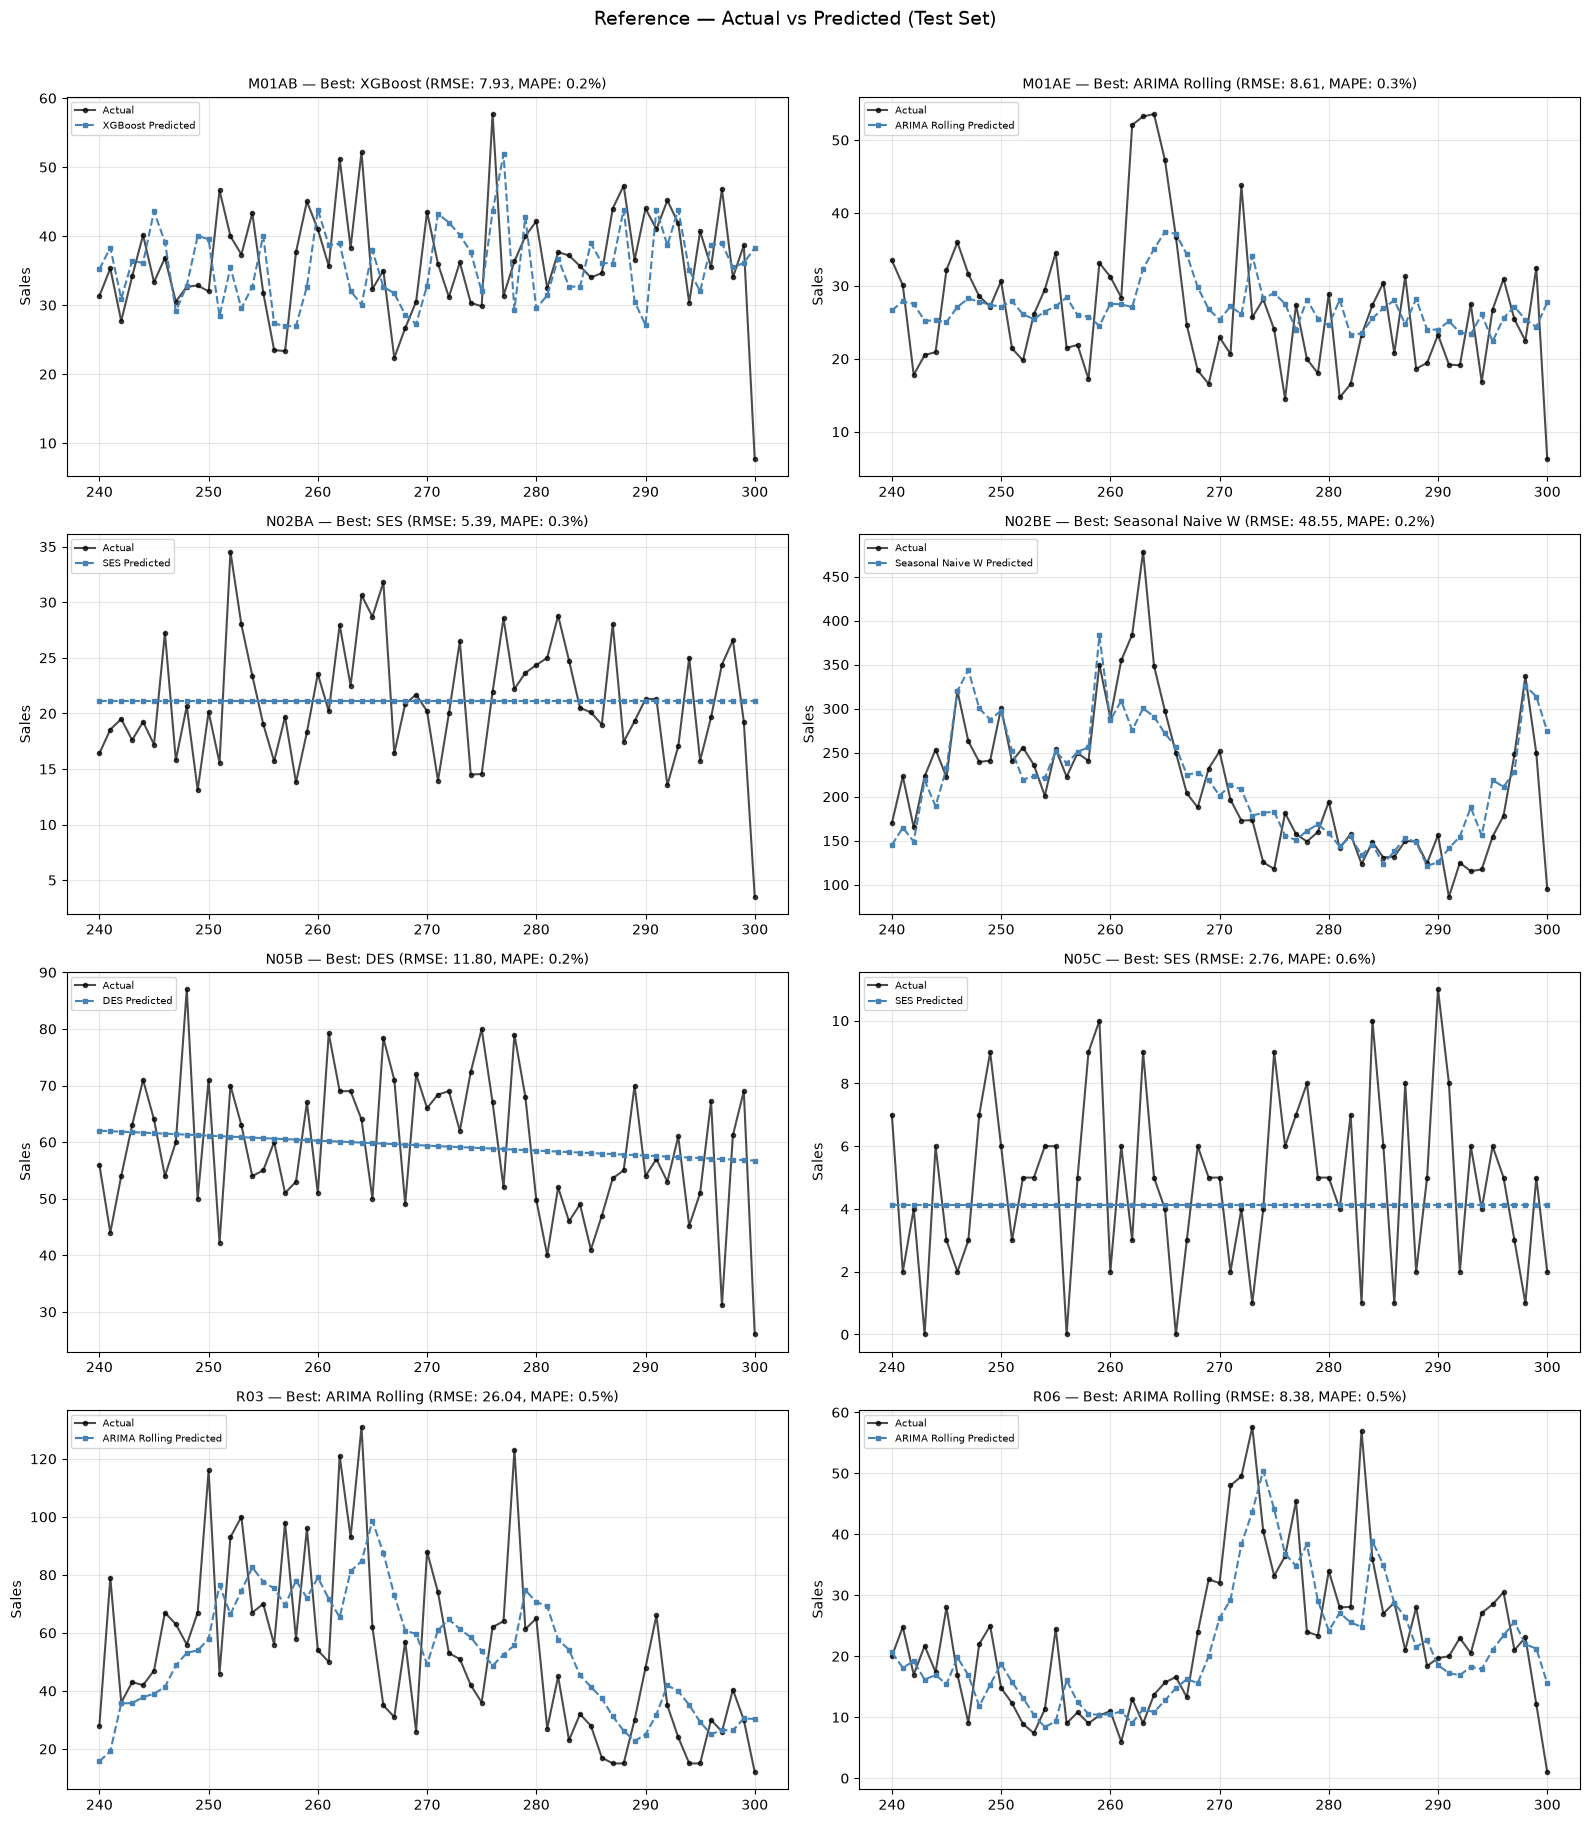

In [149]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, row in ref_best.iterrows():
    cat = row["Category"]
    method = row["Method"]
    item_list = [d for d in ref_categories if d["Category"] == cat]
    if not item_list:
        continue
    item = item_list[0]
    train_y = item["y_train"]
    test_y = item["y_test"]
    train_size = len(train_y)

    ax = axes[idx]
    ax.plot(range(train_size, train_size + len(test_y)), test_y, "o-", color="black", linewidth=1.5, markersize=3, label="Actual", alpha=0.7)

    try:
        if method == "Naive":
            test_pred = np.array([train_y[-1]] + list(test_y[:-1]))
        elif method == "Seasonal Naive W":
            _, test_pred = weighted_seasonal_naive_predict(train_y, test_y, SEASONAL_PERIOD, [0.4, 0.3, 0.2, 0.1])
        elif method in ["SES", "DES", "TES"]:
            if method == "SES":
                model = SimpleExpSmoothing(train_y, initialization_method="estimated")
            elif method == "DES":
                model = ExponentialSmoothing(train_y, trend="add", seasonal=None, initialization_method="estimated")
            else:
                model = ExponentialSmoothing(train_y, trend="add", seasonal="add", seasonal_periods=min(SEASONAL_PERIOD, max(2, len(train_y) // 2)), initialization_method="estimated")
            fit = model.fit(optimized=True)
            test_pred = fit.forecast(len(test_y))
        elif method == "ARIMA Rolling":
            initial_model = auto_arima(train_y, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=5, max_q=5)
            order = tuple(initial_model.order)
            history = list(train_y)
            preds = []
            for actual in test_y:
                m = ARIMA(history, order=order)
                mf = m.fit()
                preds.append(mf.forecast(steps=1)[0])
                history.append(actual)
            test_pred = np.array(preds)
        elif method == "ARIMA Long-Term":
            best_mse = np.inf
            best_order = (1, 1, 1)
            for p in range(0, 4):
                for d in range(0, 2):
                    for q in range(0, 4):
                        try:
                            m2 = ARIMA(train_y, order=(p, d, q))
                            f2 = m2.fit()
                            p2 = f2.predict(start=0, end=len(train_y)-1)
                            mse_val = mean_squared_error(train_y, p2)
                            if mse_val < best_mse:
                                best_mse = mse_val
                                best_order = (p, d, q)
                        except Exception:
                            continue
            fitted = ARIMA(train_y, order=best_order).fit()
            test_pred = fitted.forecast(steps=len(test_y))
        elif method == "XGBoost":
            X_train = item["X_train"]
            y_train_orig = item["y_train"]
            X_test = item["X_test"]
            xgb_final = xgb.XGBRegressor(objective="reg:squarederror", subsample=0.8, n_estimators=100, max_depth=3, random_state=RANDOM_STATE, n_jobs=-1)
            xgb_final.fit(X_train, y_train_orig)
            test_pred = xgb_final.predict(X_test)
        elif method == "Prophet":
            train_df = item["train_df"][["ds", "y"]].copy()
            test_df = item["test_df"][["ds", "y"]].copy()
            prophet_model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto", interval_width=0.0005)
            prophet_model.fit(train_df)
            future = prophet_model.make_future_dataframe(periods=len(test_df), freq="W")
            forecast = prophet_model.predict(future)
            test_pred = forecast["yhat"].to_numpy(dtype=float)[-len(test_df):]
        elif method == "LSTM":
            X_train = item["X_train"]
            y_train_orig = item["y_train"]
            X_test = item["X_test"]
            N_STEPS = 3
            Xt_seq, yt_seq = [], []
            for i in range(N_STEPS, len(X_train)):
                Xt_seq.append(X_train[i-N_STEPS:i].flatten())
                yt_seq.append(y_train_orig[i])
            Xt_seq = np.array(Xt_seq).reshape(-1, N_STEPS, X_train.shape[1])
            Xe_seq = []
            for i in range(N_STEPS, len(X_test)):
                Xe_seq.append(X_test[i-N_STEPS:i].flatten())
            Xe_seq = np.array(Xe_seq).reshape(-1, N_STEPS, X_test.shape[1])
            lstm_model = Sequential([KerasLSTM(50, activation="relu", input_shape=(N_STEPS, X_train.shape[1])), Dropout(0.2), Dense(1)])
            lstm_model.compile(optimizer="adam", loss="mse")
            lstm_model.fit(Xt_seq, np.array(yt_seq), epochs=100, batch_size=16, verbose=0, callbacks=[EarlyStopping(monitor="loss", patience=10)])
            pred_raw = lstm_model.predict(Xe_seq, verbose=0).flatten()
            test_pred = np.full(len(test_y), np.mean(train_y))
            test_pred[N_STEPS:] = pred_raw
        else:
            test_pred = np.full(len(test_y), np.mean(train_y))
    except Exception as exc:
        test_pred = np.full(len(test_y), np.mean(train_y))

    test_pred = np.maximum(test_pred, 0)
    ax.plot(range(train_size, train_size + len(test_y)), test_pred, "s--", color="steelblue", linewidth=1.5, markersize=3, label=f"{method} Predicted")
    ax.set_title(f"{cat} — Best: {method} (RMSE: {row["Test RMSE"]:.2f}, MAPE: {row["MAPE"]:.1f}%)", fontsize=10)
    ax.set_ylabel("Sales")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle("Reference — Actual vs Predicted (Test Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# Exploration Based on Our Preprocessing

Exploration using our own preprocessing pipeline. Statistical models use raw y values from the ACF+lag+rolling_mean transformed data. ML models (XGBoost) use the full lag feature matrix. Prophet and LSTM are placeholders.


## Preprocessing

Preprocessing pipeline includes weekly data loading, ACF lag selection per category, feature engineering (lag features + rolling mean), and chronological split (80/20).


In [150]:
max_lags = {}

for category in CATEGORIES:
    acf_values = acf(data[category], nlags=MAX_LAG)
    max_lags[category] = int(np.argmax(acf_values[1:]) + 1)

pd.DataFrame({"Category": list(max_lags.keys()), "n_lags": list(max_lags.values())})

,Category,n_lags
0,M01AB,2
1,M01AE,1
2,N02BA,1
3,N02BE,1
4,N05B,1
5,N05C,10
6,R03,1
7,R06,1


In [151]:
transformed_categories = []

for category in CATEGORIES:
    dfg = data[["datum", category]].rename(columns={"datum": "ds", category: "y"}).copy()
    dfg["ds"] = pd.to_datetime(dfg["ds"])

    lag_selected = max_lags[category]
    for lag in range(1, lag_selected + 1):
        dfg[f"lag_{lag}"] = dfg["y"].shift(lag)
    dfg[f"rolling_mean_{lag_selected}"] = dfg["y"].shift(1).rolling(window=lag_selected).mean()
    dfg = dfg.dropna().reset_index(drop=True)

    train_size = int(len(dfg) * 0.8)
    val_size = int(len(dfg) * 0.0)
    test_start = train_size + val_size

    dfg_train = dfg.iloc[:train_size]
    dfg_val = dfg.iloc[train_size:test_start]
    dfg_test = dfg.iloc[test_start:]
    feature_columns = [column for column in dfg.columns if column not in ["ds", "y"]]

    transformed_categories.append({
        "Category": category,
        "n_lags": lag_selected,
        "feature_columns": feature_columns,
        "df": dfg,
        "train_df": dfg_train,
        "val_df": dfg_val,
        "test_df": dfg_test,
        "X_train": dfg_train[feature_columns].to_numpy(dtype=float),
        "y_train": dfg_train["y"].to_numpy(dtype=float),
        "X_test": dfg_test[feature_columns].to_numpy(dtype=float),
        "y_test": dfg_test["y"].to_numpy(dtype=float),
    })

pd.DataFrame([
    {
        "Category": item["Category"],
        "n_lags": item["n_lags"],
        "n_features": len(item["feature_columns"]),
        "train_size": len(item["y_train"]),
        "validation_size": len(item["val_df"]),
        "test_size": len(item["y_test"]),
    }
    for item in transformed_categories
])

,Category,n_lags,n_features,train_size,validation_size,test_size
0,M01AB,2,3,240,0,60
1,M01AE,1,2,240,0,61
2,N02BA,1,2,240,0,61
3,N02BE,1,2,240,0,61
4,N05B,1,2,240,0,61
5,N05C,10,11,233,0,59
6,R03,1,2,240,0,61
7,R06,1,2,240,0,61


## Modeling

Same 10 models from Reference section, evaluated with our preprocessing pipeline. Statistical models use raw y values; XGBoost uses ACF lag + rolling mean features. Prophet and LSTM are placeholders.


### Naive

Simple Naive forecast: `y_pred[t] = y[t-1]`. Uses raw y from transformed data.


In [152]:
our_records = []
_Naive_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    train_pred = np.array([train_y[i-1] if i > 0 else train_y[0] for i in range(len(train_y))])
    test_pred = np.array([train_y[-1]] + list(test_y[:-1]))

    train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
    test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    train_rmse = float(root_mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))
    test_rmse = float(root_mean_squared_error(test_y, test_pred))
    mask = test_y != 0
    test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan

    add_result(_Naive_results, category, "Naive", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, comment="Naive on Our preprocessing y.")

our_records.extend(_Naive_results)
pd.DataFrame(_Naive_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,Naive,0,{},116.703844,10.802955,100.950798,10.047427,0.261924,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.
1,M01AE,Naive,0,{},58.499755,7.648513,83.291220,9.126402,0.329417,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.
2,N02BA,Naive,0,{},77.852007,8.823378,45.478852,6.743801,0.331775,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.
3,N02BE,Naive,0,{},2107.236737,45.904648,2732.873738,52.276895,0.209746,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.
4,N05B,Naive,0,{},566.194318,23.794838,262.086557,16.189088,0.242410,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.
5,N05C,Naive,0,{},17.032517,4.127047,14.271186,3.777722,0.942896,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.
6,R03,Naive,0,{},441.208428,21.004962,904.344547,30.072322,0.450141,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.
7,R06,Naive,0,{},57.320211,7.571011,79.018279,8.889223,0.501683,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.


### Seasonal Naive (Weighted)

Weighted Seasonal Naive with 52-week period, weights `[0.4, 0.3, 0.2, 0.1]` (matching paper specification). Uses raw y from transformed data.


In [153]:
_Seasonal_Naive_W_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]
    weights = [0.4, 0.3, 0.2, 0.1]

    train_pred, test_pred = weighted_seasonal_naive_predict(train_y, test_y, SEASONAL_PERIOD, weights)

    train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
    test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    train_rmse = float(root_mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))
    test_rmse = float(root_mean_squared_error(test_y, test_pred))
    mask = test_y != 0
    test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan

    add_result(_Seasonal_Naive_W_results, category, "Seasonal Naive W", 0, train_mse, train_rmse, test_mse, test_rmse, test_mape_val, {"seasonal_period": SEASONAL_PERIOD, "weights": weights}, "Weighted Seasonal Naive on Our preprocessing y.")

our_records.extend(_Seasonal_Naive_W_results)
pd.DataFrame(_Seasonal_Naive_W_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",111.369453,10.553173,72.129887,8.492932,0.236655,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.
1,M01AE,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",83.148990,9.118607,82.641344,9.090728,0.336939,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.
2,N02BA,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",80.899086,8.994392,73.248956,8.558560,0.451500,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.
3,N02BE,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",4331.727694,65.815862,2357.228876,48.551301,0.177334,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.
4,N05B,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",906.645986,30.110563,211.764610,14.552134,0.210566,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.
5,N05C,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",13.340979,3.652530,11.106512,3.332643,0.688246,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.
6,R03,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",367.170209,19.161686,1024.350090,32.005470,0.491917,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.
7,R06,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",84.225038,9.177420,80.338479,8.963173,0.508508,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.


### Exponential Smoothing (SES, DES, TES)

Simple Exponential Smoothing (SES), Double Exponential Smoothing (DES/Holt), and Triple Exponential Smoothing (TES/Holt-Winters). Models use optimized fitting via statsmodels. DES uses additive trend without seasonality. TES uses additive trend + additive seasonality with period 52.


In [154]:
_Model_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    smoothing_specs = [
        ("SES", SimpleExpSmoothing, {"initialization_method": "estimated"}, {}),
        ("DES", ExponentialSmoothing, {"trend": "add", "seasonal": None, "initialization_method": "estimated"}, {}),
        ("TES", ExponentialSmoothing, {"trend": "add", "seasonal": "add", "seasonal_periods": min(SEASONAL_PERIOD, max(2, len(train_y) // 2)), "initialization_method": "estimated"}, {"seasonal_period": min(SEASONAL_PERIOD, max(2, len(train_y) // 2))}),
    ]

    for method, model_class, model_kwargs, params in smoothing_specs:
        try:
            model = model_class(train_y, **model_kwargs)
            fit = model.fit(optimized=True)
            train_pred = fit.fittedvalues
            test_pred = fit.forecast(len(test_y))

            train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
            test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
            train_mse = float(mean_squared_error(train_y[-len(train_pred):], train_pred))
            train_rmse = float(root_mean_squared_error(train_y[-len(train_pred):], train_pred))
            test_mse = float(mean_squared_error(test_y, test_pred))
            test_rmse = float(root_mean_squared_error(test_y, test_pred))
            mask = test_y != 0
            test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan
            comment = "Our preprocessing SES/DES/TES on aligned y."
        except Exception as exc:
            train_mse = train_rmse = test_mse = test_rmse = np.nan
            test_mape_val = np.nan
            comment = f"{method} failed: {repr(exc)}"

        add_result(_Model_results, category, method, item["n_lags"], train_mse, train_rmse, test_mse, test_rmse, test_mape_val, params, comment)

our_records.extend(_Model_results)
pd.DataFrame(_Model_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,SES,2,{},59.994383,7.745604,68.843968,8.297227,0.205215,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
1,M01AB,DES,2,{},59.965254,7.743724,65.147142,8.071378,0.203149,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
2,M01AB,TES,2,"{""seasonal_period"": 52}",47.423904,6.886502,75.914453,8.712890,0.226481,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
3,M01AE,SES,1,{},36.150773,6.012551,86.510327,9.301093,0.309010,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
4,M01AE,DES,1,{},36.140463,6.011694,87.302126,9.343561,0.316059,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
5,M01AE,TES,1,"{""seasonal_period"": 52}",25.466021,5.046387,86.186126,9.283648,0.353964,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
6,N02BA,SES,1,{},47.793320,6.913271,29.031728,5.388110,0.273907,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
7,N02BA,DES,1,{},47.565701,6.896789,36.363237,6.030194,0.264470,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
8,N02BA,TES,1,"{""seasonal_period"": 52}",28.326524,5.322267,45.281634,6.729163,0.306847,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
9,N02BE,SES,1,{},1918.342880,43.798891,11483.951980,107.163203,0.324705,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.


### ARIMA Rolling

ARIMA with rolling expanding window forecast. Order is selected via auto_arima when available, with fallback to (1,1,1). Each test point is forecast by refitting ARIMA on expanding window.


In [155]:
_ARIMA_Rolling_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    try:
        initial_model = auto_arima(train_y, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=5, max_q=5, max_d=2)
        order = tuple(initial_model.order)
        comment = "auto_arima on transformed train series."

        fitted_train = ARIMA(train_y, order=order).fit()
        train_pred = fitted_train.predict(start=0, end=len(train_y) - 1)

        history = list(train_y)
        test_pred = []
        for actual in test_y:
            model = ARIMA(history, order=order)
            model_fit = model.fit()
            test_pred.append(model_fit.forecast(steps=1)[0])
            history.append(actual)

        train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
        test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        train_rmse = float(root_mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        test_rmse = float(root_mean_squared_error(test_y, test_pred))
        mask = test_y != 0
        test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan
        params = {"order": list(order)}
    except Exception as exc:
        train_mse = train_rmse = test_mse = test_rmse = np.nan
        test_mape_val = np.nan
        params = {}
        comment = f"ARIMA Rolling failed: {repr(exc)}"

    add_result(_ARIMA_Rolling_results, category, "ARIMA Rolling", item["n_lags"], train_mse, train_rmse, test_mse, test_rmse, test_mape_val, params, comment)

our_records.extend(_ARIMA_Rolling_results)
pd.DataFrame(_ARIMA_Rolling_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,ARIMA Rolling,2,"{""order"": [0, 1, 1]}",64.090021,8.005624,66.084871,8.129260,0.213204,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.
1,M01AE,ARIMA Rolling,1,"{""order"": [1, 1, 1]}",36.805943,6.066790,74.137333,8.610304,0.313565,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.
2,N02BA,ARIMA Rolling,1,"{""order"": [0, 1, 1]}",54.383537,7.374519,30.970286,5.565095,0.282163,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.
3,N02BE,ARIMA Rolling,1,"{""order"": [2, 0, 0]}",1820.665791,42.669260,2525.413100,50.253488,0.197234,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.
4,N05B,ARIMA Rolling,1,"{""order"": [0, 1, 1]}",415.965433,20.395231,149.741650,12.236897,0.184389,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.
5,N05C,ARIMA Rolling,10,"{""order"": [3, 0, 0]}",9.446729,3.073553,7.992057,2.827023,0.611185,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.
6,R03,ARIMA Rolling,1,"{""order"": [0, 1, 1]}",285.931172,16.909499,677.915951,26.036819,0.478674,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.
7,R06,ARIMA Rolling,1,"{""order"": [2, 0, 2]}",43.290403,6.579544,70.254707,8.381808,0.510360,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.


### ARIMA Long-Term

ARIMA with long-term forecast. Order selected via grid search (p:0-3, d:0-1, q:0-3). Uses raw y from transformed data.


In [156]:
_ARIMA_Long_Term_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y_full = item["y_train"]
    test_y = item["y_test"]

    try:
        best_mse = np.inf
        best_order = (1, 1, 1)
        for p in range(0, 4):
            for d in range(0, 2):
                for q in range(0, 4):
                    try:
                        model = ARIMA(train_y_full, order=(p, d, q))
                        fitted = model.fit()
                        pred = fitted.predict(start=0, end=len(train_y_full) - 1)
                        mse_val = mean_squared_error(train_y_full, pred)
                        if mse_val < best_mse:
                            best_mse = mse_val
                            best_order = (p, d, q)
                    except Exception:
                        continue

        fitted = ARIMA(train_y_full, order=best_order).fit()
        train_pred = fitted.predict(start=0, end=len(train_y_full) - 1)
        test_pred = fitted.forecast(steps=len(test_y))

        train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
        test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
        train_mse = float(mean_squared_error(train_y_full, train_pred))
        train_rmse = float(root_mean_squared_error(train_y_full, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        test_rmse = float(root_mean_squared_error(test_y, test_pred))
        mask = test_y != 0
        test_mape_val = float(mean_absolute_percentage_error(test_y[mask], test_pred[mask])) if mask.sum() > 0 else np.nan
        params = {"order": list(best_order)}
        comment = "ARIMA Long-Term on transformed train series."
    except Exception as exc:
        train_mse = train_rmse = test_mse = test_rmse = np.nan
        test_mape_val = np.nan
        params = {}
        comment = f"ARIMA Long-Term failed: {repr(exc)}"

    add_result(_ARIMA_Long_Term_results, category, "ARIMA Long-Term", item["n_lags"], train_mse, train_rmse, test_mse, test_rmse, test_mape_val, params, comment)

our_records.extend(_ARIMA_Long_Term_results)
pd.DataFrame(_ARIMA_Long_Term_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,ARIMA Long-Term,2,"{""order"": [3, 0, 3]}",56.113528,7.490896,80.170445,8.953795,0.234146,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.
1,M01AE,ARIMA Long-Term,1,"{""order"": [3, 0, 3]}",34.955703,5.912335,86.962432,9.325365,0.318930,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.
2,N02BA,ARIMA Long-Term,1,"{""order"": [3, 0, 3]}",47.031080,6.857921,50.861860,7.131750,0.411054,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.
3,N02BE,ARIMA Long-Term,1,"{""order"": [3, 0, 3]}",1763.457877,41.993546,6888.533929,82.997192,0.355285,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.
4,N05B,ARIMA Long-Term,1,"{""order"": [3, 0, 3]}",360.743743,18.993255,160.470435,12.667693,0.206629,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.
5,N05C,ARIMA Long-Term,10,"{""order"": [3, 0, 3]}",8.916461,2.986044,8.327879,2.885806,0.601276,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.
6,R03,ARIMA Long-Term,1,"{""order"": [3, 0, 3]}",266.570529,16.326988,1361.475601,36.898179,0.505315,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.
7,R06,ARIMA Long-Term,1,"{""order"": [3, 0, 2]}",43.281282,6.578851,117.724378,10.850087,0.541031,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.


### XGBoost

XGBoost regressor using ACF lag + rolling mean features from final-paper weekly preprocessing. GridSearchCV with TimeSeriesSplit for hyperparameter tuning.


In [157]:
_XGBoost_results = []

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
}

for item in transformed_categories:
    category = item["Category"]
    X_train = item["X_train"]
    y_train = item["y_train"]
    X_test = item["X_test"]
    y_test = item["y_test"]

    tscv = TimeSeriesSplit(n_splits=3)
    xgb_base = xgb.XGBRegressor(objective="reg:squarederror", subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1)
    grid_search = GridSearchCV(xgb_base, param_grid, scoring="neg_mean_squared_error", cv=tscv)
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_

    xgb_final = xgb.XGBRegressor(objective="reg:squarederror", subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, **best_params)
    xgb_final.fit(X_train, y_train)

    train_pred = xgb_final.predict(X_train)
    test_pred = xgb_final.predict(X_test)

    train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
    test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
    train_mse = float(mean_squared_error(y_train, train_pred))
    train_rmse = float(root_mean_squared_error(y_train, train_pred))
    test_mse = float(mean_squared_error(y_test, test_pred))
    test_rmse = float(root_mean_squared_error(y_test, test_pred))
    mask = y_test != 0
    test_mape_val = float(mean_absolute_percentage_error(y_test[mask], test_pred[mask])) if mask.sum() > 0 else np.nan

    add_result(_XGBoost_results, category, "XGBoost", item["n_lags"], train_mse, train_rmse, test_mse, test_rmse, test_mape_val, best_params, "XGBoost with Our preprocessing ACF lag + rolling features.")

our_records.extend(_XGBoost_results)
pd.DataFrame(_XGBoost_results)


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,XGBoost,2,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",45.260080,6.727561,68.219830,8.259530,0.208927,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,XGBoost with Our preprocessing ACF lag + rolli...
1,M01AE,XGBoost,1,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",29.575623,5.438347,75.448393,8.686103,0.306433,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,XGBoost with Our preprocessing ACF lag + rolli...
2,N02BA,XGBoost,1,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",43.741839,6.613761,66.876624,8.177813,0.456447,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,XGBoost with Our preprocessing ACF lag + rolli...
3,N02BE,XGBoost,1,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",1422.861439,37.720836,2470.505116,49.704176,0.192244,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,XGBoost with Our preprocessing ACF lag + rolli...
4,N05B,XGBoost,1,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",356.363615,18.877596,178.766634,13.370364,0.199719,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,XGBoost with Our preprocessing ACF lag + rolli...
5,N05C,XGBoost,10,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",6.181378,2.486238,7.438156,2.727298,0.595334,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,XGBoost with Our preprocessing ACF lag + rolli...
6,R03,XGBoost,1,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",251.202678,15.849375,993.662173,31.522407,0.435425,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,XGBoost with Our preprocessing ACF lag + rolli...
7,R06,XGBoost,1,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti...",35.087168,5.923442,83.967252,9.163365,0.493990,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,XGBoost with Our preprocessing ACF lag + rolli...


### Facebook Prophet

Prophet additive forecasting model with weekly and yearly seasonality. Fits on raw y time-series from our preprocessing pipeline.


In [158]:
_Prophet_results = []

for item in transformed_categories:
    category = item["Category"]
    train_df = item["train_df"][["ds", "y"]].copy()
    test_df = item["test_df"][["ds", "y"]].copy()

    try:
        model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto", interval_width=0.0005)
        model.fit(train_df)
        future = model.make_future_dataframe(periods=len(test_df), freq="W")
        forecast = model.predict(future)

        train_pred = forecast["yhat"].to_numpy(dtype=float)[:len(train_df)]
        test_pred = forecast["yhat"].to_numpy(dtype=float)[-len(test_df):]

        train_pred = np.maximum(np.asarray(train_pred, dtype=float), 0)
        test_pred = np.maximum(np.asarray(test_pred, dtype=float), 0)
        train_mse = float(mean_squared_error(item["y_train"], train_pred))
        train_rmse = float(root_mean_squared_error(item["y_train"], train_pred))
        test_mse = float(mean_squared_error(item["y_test"], test_pred))
        test_rmse = float(root_mean_squared_error(item["y_test"], test_pred))
        mask = item["y_test"] != 0
        test_mape_val = float(mean_absolute_percentage_error(item["y_test"][mask], test_pred[mask])) if mask.sum() > 0 else np.nan
        comment = "Prophet on our preprocessing y."
    except Exception as exc:
        train_mse = train_rmse = test_mse = test_rmse = np.nan
        test_mape_val = np.nan
        comment = f"Prophet failed: {repr(exc)}"

    add_result(_Prophet_results, category, "Prophet", item["n_lags"], train_mse, train_rmse, test_mse, test_rmse, test_mape_val, {}, comment)

our_records.extend(_Prophet_results)
pd.DataFrame(_Prophet_results)


17:40:24 - cmdstanpy - INFO - Chain [1] start processing
17:40:24 - cmdstanpy - INFO - Chain [1] done processing
17:40:24 - cmdstanpy - INFO - Chain [1] start processing
17:40:24 - cmdstanpy - INFO - Chain [1] done processing
17:40:24 - cmdstanpy - INFO - Chain [1] start processing
17:40:24 - cmdstanpy - INFO - Chain [1] done processing
17:40:25 - cmdstanpy - INFO - Chain [1] start processing
17:40:25 - cmdstanpy - INFO - Chain [1] done processing
17:40:25 - cmdstanpy - INFO - Chain [1] start processing
17:40:25 - cmdstanpy - INFO - Chain [1] done processing
17:40:25 - cmdstanpy - INFO - Chain [1] start processing
17:40:25 - cmdstanpy - INFO - Chain [1] done processing
17:40:25 - cmdstanpy - INFO - Chain [1] start processing
17:40:25 - cmdstanpy - INFO - Chain [1] done processing
17:40:26 - cmdstanpy - INFO - Chain [1] start processing
17:40:26 - cmdstanpy - INFO - Chain [1] done processing


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,Prophet,2,{},54.499835,7.382400,89.189816,9.444036,0.234232,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.
1,M01AE,Prophet,1,{},28.554179,5.343611,75.674990,8.699137,0.287502,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.
2,N02BA,Prophet,1,{},38.245635,6.184306,44.027534,6.635325,0.290422,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.
3,N02BE,Prophet,1,{},1864.026502,43.174373,3541.740821,59.512527,0.197495,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.
4,N05B,Prophet,1,{},452.573197,21.273768,248.061191,15.749958,0.206557,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.
5,N05C,Prophet,10,{},8.997424,2.999571,10.089551,3.176405,0.574545,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.
6,R03,Prophet,1,{},218.170035,14.770580,807.716721,28.420358,0.482438,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.
7,R06,Prophet,1,{},37.507320,6.124322,73.032263,8.545892,0.566233,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.


### LSTM Neural Network

LSTM with 3-step sliding window on ACF lag + rolling mean features. Architecture: LSTM(50) → Dropout(0.2) → Dense(1). Same training config as Reference section.


In [159]:
_LSTM_results = []

for item in transformed_categories:
    category = item["Category"]
    X_train = item["X_train"]
    y_train = item["y_train"]
    X_test = item["X_test"]
    y_test = item["y_test"]

    print(f"Running {category}...")

    try:
        X_train_seq, y_train_seq = [], []
        for i in range(N_STEPS, len(X_train)):
            X_train_seq.append(X_train[i-N_STEPS:i].flatten())
            y_train_seq.append(y_train[i])
        X_train_seq = np.array(X_train_seq).reshape(-1, N_STEPS, -1)
        y_train_seq = np.array(y_train_seq)

        X_test_seq, y_test_seq = [], []
        for i in range(N_STEPS, len(X_test)):
            X_test_seq.append(X_test[i-N_STEPS:i].flatten())
            y_test_seq.append(y_test[i])
        X_test_seq = np.array(X_test_seq).reshape(-1, N_STEPS, -1)
        y_test_seq = np.array(y_test_seq)

        n_features = X_train.shape[1]
        model = Sequential([
            KerasLSTM(50, activation="relu", return_sequences=False, input_shape=(N_STEPS, n_features)),
            Dropout(0.2),
            Dense(1)
        ])
        model.compile(optimizer="adam", loss="mse")
        model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=16, validation_split=0.1, verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])

        train_pred = model.predict(X_train_seq, verbose=0).flatten()
        test_pred = model.predict(X_test_seq, verbose=0).flatten()

        train_pred_full = np.full(len(y_train), np.mean(y_train))
        train_pred_full[-len(train_pred):] = train_pred
        test_pred_full = np.full(len(y_test), np.mean(y_train))
        test_pred_full[N_STEPS:] = test_pred

        train_pred_full = np.maximum(train_pred_full, 0)
        test_pred_full = np.maximum(test_pred_full, 0)
        train_mse = float(mean_squared_error(y_train, train_pred_full))
        train_rmse = float(root_mean_squared_error(y_train, train_pred_full))
        test_mse = float(mean_squared_error(y_test, test_pred_full))
        test_rmse = float(root_mean_squared_error(y_test, test_pred_full))
        mask = y_test != 0
        test_mape_val = float(mean_absolute_percentage_error(y_test[mask], test_pred_full[mask])) if mask.sum() > 0 else np.nan
        comment = "LSTM on Our preprocessing ACF lag features."
    except Exception as exc:
        train_mse = train_rmse = test_mse = test_rmse = np.nan
        test_mape_val = np.nan
        comment = f"LSTM failed: {repr(exc)}"

    add_result(_LSTM_results, category, "LSTM", item["n_lags"], train_mse, train_rmse, test_mse, test_rmse, test_mape_val, {"n_steps": N_STEPS}, comment)

our_records.extend(_LSTM_results)
pd.DataFrame(_LSTM_results)


Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
0,M01AB,LSTM,2,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...
1,M01AE,LSTM,1,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...
2,N02BA,LSTM,1,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...
3,N02BE,LSTM,1,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...
4,N05B,LSTM,1,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...
5,N05C,LSTM,10,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...
6,R03,LSTM,1,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...
7,R06,LSTM,1,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...


## Our Results

Combine all our model results into one DataFrame.


In [160]:
our_results_df = pd.DataFrame(our_records).sort_values(["Category", "Method"])
our_results_df["params"] = our_results_df["params"].apply(lambda p: json.dumps(p, sort_keys=True) if isinstance(p, dict) else p)
our_results_df


,Category,Method,n_lags,params,Train MSE,Train RMSE,Test MSE,Test RMSE,MAPE,split,target_scale,metric_family,comment
48,M01AB,ARIMA Long-Term,2,"{""order"": [3, 0, 3]}",56.113528,7.490896,80.170445,8.953795,0.234146,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,ARIMA Long-Term on transformed train series.
40,M01AB,ARIMA Rolling,2,"{""order"": [0, 1, 1]}",64.090021,8.005624,66.084871,8.129260,0.213204,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,auto_arima on transformed train series.
17,M01AB,DES,2,{},59.965254,7.743724,65.147142,8.071378,0.203149,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
72,M01AB,LSTM,2,"{""n_steps"": 3}",NaN,NaN,NaN,NaN,NaN,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,LSTM failed: ValueError('can only specify one ...
0,M01AB,Naive,0,{},116.703844,10.802955,100.950798,10.047427,0.261924,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Naive on Our preprocessing y.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,R06,Prophet,1,{},37.507320,6.124322,73.032263,8.545892,0.566233,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Prophet on our preprocessing y.
37,R06,SES,1,{},47.315786,6.878647,151.598951,12.312553,0.984577,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.
15,R06,Seasonal Naive W,0,"{""seasonal_period"": 52, ""weights"": [0.4, 0.3, ...",84.225038,9.177420,80.338479,8.963173,0.508508,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Weighted Seasonal Naive on Our preprocessing y.
39,R06,TES,1,"{""seasonal_period"": 52}",33.235738,5.765044,72.708922,8.526953,0.702589,chronological 80/20,original weekly sales scale; no target scaling,MSE/RMSE/MAPE,Our preprocessing SES/DES/TES on aligned y.


## Best Baseline & Export (Our Preprocessing)

Best model per category based on lowest Test MSE. Includes line chart comparison.


In [161]:
our_best = our_results_df.loc[our_results_df.groupby("Category")["Test MSE"].idxmin()].reset_index(drop=True)

our_table = our_best[["Category", "Method", "Test MSE", "Test RMSE", "MAPE"]].reset_index(drop=True)
our_table


,Category,Method,Test MSE,Test RMSE,MAPE
0,M01AB,DES,65.147142,8.071378,0.203149
1,M01AE,ARIMA Rolling,74.137333,8.610304,0.313565
2,N02BA,SES,29.031728,5.388110,0.273907
3,N02BE,Seasonal Naive W,2357.228876,48.551301,0.177334
4,N05B,DES,139.128637,11.795280,0.186422
5,N05C,XGBoost,7.438156,2.727298,0.595334
6,R03,ARIMA Rolling,677.915951,26.036819,0.478674
7,R06,ARIMA Rolling,70.254707,8.381808,0.510360


### Plot actual vs predicted for best model per category (Reference)

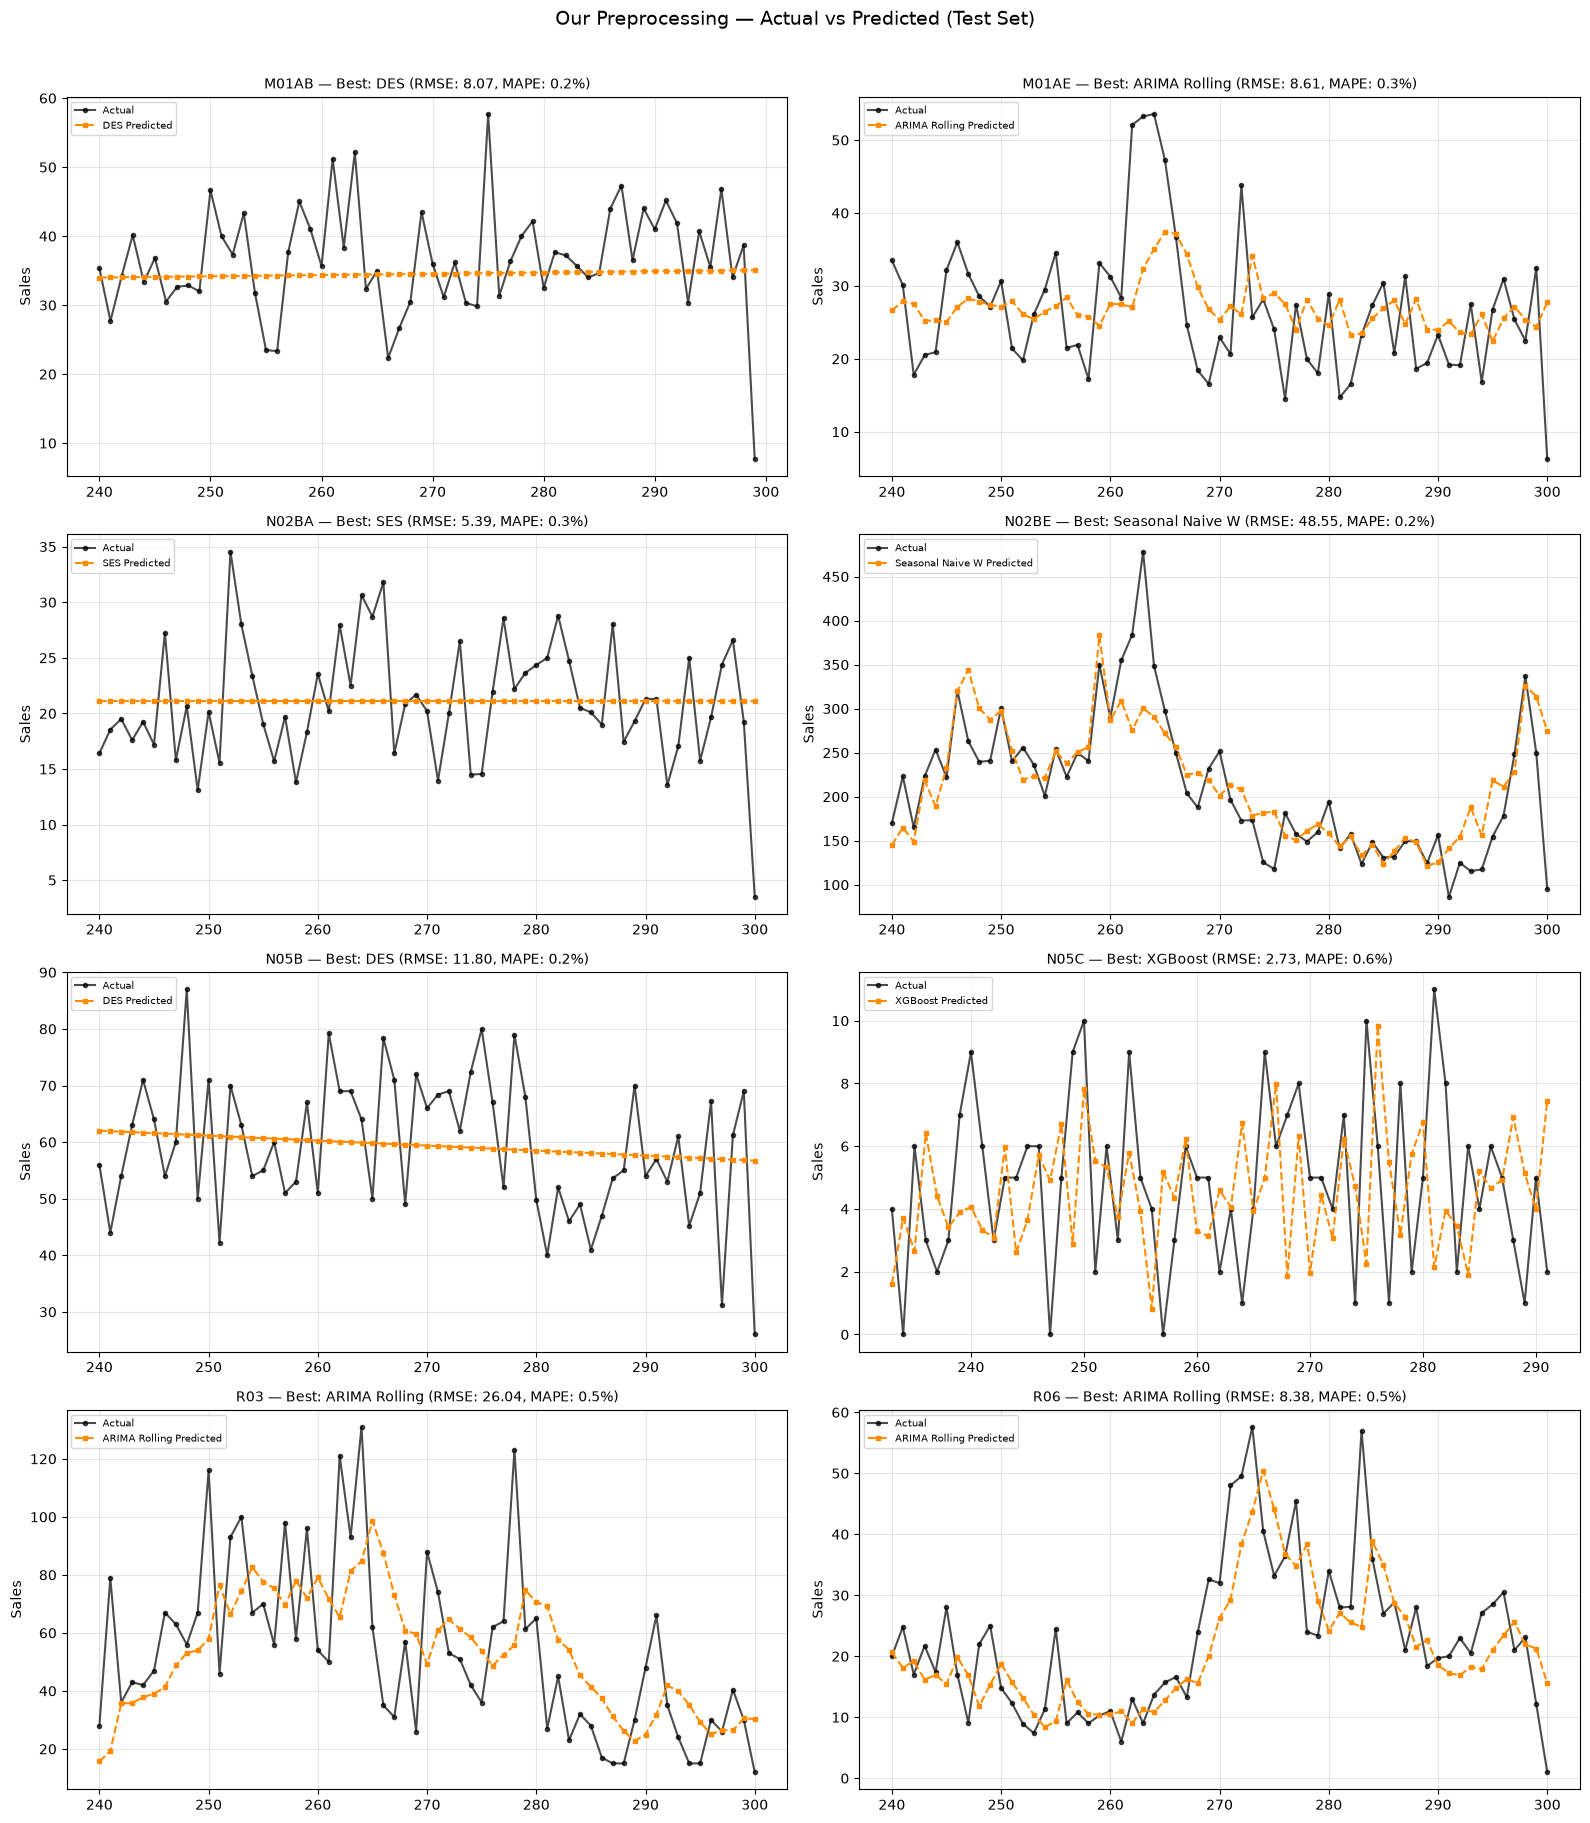

In [162]:
# Plot actual vs predicted for best model per category (Our Preprocessing)
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, row in our_best.iterrows():
    cat = row["Category"]
    method = row["Method"]
    item_list = [d for d in transformed_categories if d["Category"] == cat]
    if not item_list:
        continue
    item = item_list[0]
    train_y = item["y_train"]
    test_y = item["y_test"]
    train_size = len(train_y)

    ax = axes[idx]
    ax.plot(range(train_size, train_size + len(test_y)), test_y, "o-", color="black", linewidth=1.5, markersize=3, label="Actual", alpha=0.7)

    try:
        if method == "Naive":
            test_pred = np.array([train_y[-1]] + list(test_y[:-1]))
        elif method == "Seasonal Naive W":
            _, test_pred = weighted_seasonal_naive_predict(train_y, test_y, SEASONAL_PERIOD, [0.4, 0.3, 0.2, 0.1])
        elif method in ["SES", "DES", "TES"]:
            if method == "SES":
                model = SimpleExpSmoothing(train_y, initialization_method="estimated")
            elif method == "DES":
                model = ExponentialSmoothing(train_y, trend="add", seasonal=None, initialization_method="estimated")
            else:
                model = ExponentialSmoothing(train_y, trend="add", seasonal="add", seasonal_periods=min(SEASONAL_PERIOD, max(2, len(train_y) // 2)), initialization_method="estimated")
            fit = model.fit(optimized=True)
            test_pred = fit.forecast(len(test_y))
        elif method == "ARIMA Rolling":
            initial_model = auto_arima(train_y, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=5, max_q=5)
            order = tuple(initial_model.order)
            history = list(train_y)
            preds = []
            for actual in test_y:
                m = ARIMA(history, order=order)
                mf = m.fit()
                preds.append(mf.forecast(steps=1)[0])
                history.append(actual)
            test_pred = np.array(preds)
        elif method == "ARIMA Long-Term":
            best_mse = np.inf
            best_order = (1, 1, 1)
            for p in range(0, 4):
                for d in range(0, 2):
                    for q in range(0, 4):
                        try:
                            m2 = ARIMA(train_y, order=(p, d, q))
                            f2 = m2.fit()
                            p2 = f2.predict(start=0, end=len(train_y)-1)
                            mse_val = mean_squared_error(train_y, p2)
                            if mse_val < best_mse:
                                best_mse = mse_val
                                best_order = (p, d, q)
                        except Exception:
                            continue
            fitted = ARIMA(train_y, order=best_order).fit()
            test_pred = fitted.forecast(steps=len(test_y))
        elif method == "XGBoost":
            X_train = item["X_train"]
            X_test = item["X_test"]
            xgb_final = xgb.XGBRegressor(objective="reg:squarederror", subsample=0.8, n_estimators=100, max_depth=3, random_state=RANDOM_STATE, n_jobs=-1)
            xgb_final.fit(X_train, train_y)
            test_pred = xgb_final.predict(X_test)
        elif method == "Prophet":
            train_df = item["train_df"][["ds", "y"]].copy()
            test_df = item["test_df"][["ds", "y"]].copy()
            prophet_model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto", interval_width=0.0005)
            prophet_model.fit(train_df)
            future = prophet_model.make_future_dataframe(periods=len(test_df), freq="W")
            forecast = prophet_model.predict(future)
            test_pred = forecast["yhat"].to_numpy(dtype=float)[-len(test_df):]
        elif method == "LSTM":
            X_train = item["X_train"]
            X_test = item["X_test"]
            N_STEPS = 3
            Xt_seq, yt_seq = [], []
            for i in range(N_STEPS, len(X_train)):
                Xt_seq.append(X_train[i-N_STEPS:i].flatten())
                yt_seq.append(train_y[i])
            Xt_seq = np.array(Xt_seq).reshape(-1, N_STEPS, -1)
            Xe_seq = []
            for i in range(N_STEPS, len(X_test)):
                Xe_seq.append(X_test[i-N_STEPS:i].flatten())
            Xe_seq = np.array(Xe_seq).reshape(-1, N_STEPS, -1)
            lstm_model = Sequential([KerasLSTM(50, activation="relu", input_shape=(N_STEPS, X_train.shape[1])), Dropout(0.2), Dense(1)])
            lstm_model.compile(optimizer="adam", loss="mse")
            lstm_model.fit(Xt_seq, np.array(yt_seq), epochs=100, batch_size=16, verbose=0, callbacks=[EarlyStopping(monitor="loss", patience=10)])
            pred_raw = lstm_model.predict(Xe_seq, verbose=0).flatten()
            test_pred = np.full(len(test_y), np.mean(train_y))
            test_pred[N_STEPS:] = pred_raw
        else:
            test_pred = np.full(len(test_y), np.mean(train_y))
    except Exception as exc:
        test_pred = np.full(len(test_y), np.mean(train_y))

    test_pred = np.maximum(test_pred, 0)
    ax.plot(range(train_size, train_size + len(test_y)), test_pred, "s--", color="darkorange", linewidth=1.5, markersize=3, label=f"{method} Predicted")
    ax.set_title(f"{cat} — Best: {method} (RMSE: {row["Test RMSE"]:.2f}, MAPE: {row["MAPE"]:.1f}%)", fontsize=10)
    ax.set_ylabel("Sales")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle("Our Preprocessing — Actual vs Predicted (Test Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# Summary

## Experimental Setup

Two preprocessing approaches compared using 10 forecasting models on 8 ATC categories with weekly pharma sales data:

| Aspect | Reference (Paper) | Our Preprocessing |
|--------|-------------------|-------------------|
| Split | 80/20 | 80/20 |
| Features (Statistical) | raw y | raw y |
| Features (ML) | `lag_1` only | ACF-based lag_n + rolling_mean |
| Seasonality | 52-week | 52-week |
| Tuning | Per model spec | Grid search / optimized fit |

## Models Evaluated

| # | Model | Type |
|---|-------|------|
| 1 | Naive | Baseline |
| 2 | Seasonal Naive (Weighted) | Statistical |
| 3 | Single Exponential Smoothing (SES) | Statistical |
| 4 | Double Exponential Smoothing (DES) | Statistical |
| 5 | Triple Exponential Smoothing (TES) | Statistical |
| 6 | ARIMA Rolling | Statistical |
| 7 | ARIMA Long-Term | Statistical |
| 8 | XGBoost | Machine Learning |
| 9 | Facebook Prophet | Statistical |
| 10 | LSTM Neural Network | Deep Learning |

## Key Metrics

- MSE (Mean Squared Error) — primary metric
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error) — as used in the paper
